# M54 Strengthening Model — Interactive Walkthrough

Quick tour of the model, calibrated against four Sun 2022 anchors. After running
this notebook end-to-end you'll have:

- a feel for the API (alloy → state → prediction),
- per-contribution decomposition for each calibration anchor,
- tempering parameter sweeps,
- a comparison of the DQ vs AF processing routes at the same temper.

See [`docs/MODEL_PLAN.md`](../docs/MODEL_PLAN.md) for the full architecture and
[`docs/FINDINGS.md`](../docs/FINDINGS.md) for the running list of insights.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from m54model import FERRIUM_M54, MicrostructuralState, assemble_yield_strength
from m54model.alloys.ferrium_m54 import (
    SUN_2022_DQ, SUN_2022_DQ_T516_10, SUN_2022_AF550_45, SUN_2022_AF550_45_T425_10,
)
from m54model.calibration import (
    sun_2022_dq, sun_2022_dq_t516_10, sun_2022_af550_45, sun_2022_af550_45_t425_10,
    evaluate_against_anchor,
)
from m54model.kinetics import m2c_population_dq_tempered, m2c_population_af_tempered
from m54model.plotting import plot_contributions, plot_anchor_dashboard, plot_tempering_sweep

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. The alloy

Ferrium M54 composition is a frozen `Composition` dataclass. Everything is
derived from this — at% conversion, Fleischer-eligible elements, etc.

In [2]:
print(f'Name: {FERRIUM_M54.name}')
print(f'wt%:  {FERRIUM_M54.wt_pct_full}')
print()
print('at%:')
for elem, x in sorted(FERRIUM_M54.at_pct().items(), key=lambda kv: -kv[1]):
    print(f'  {elem:3s}  {x:6.3f}')

Name: Ferrium M54
wt%:  {'C': 0.3, 'Cr': 1.0, 'Ni': 10.0, 'Co': 7.0, 'Mo': 2.0, 'W': 1.3, 'V': 0.1, 'Ti': 0.013, 'Fe': 78.287}

at%:
  Fe   79.409
  Ni    9.651
  Co    6.728
  C     1.415
  Mo    1.181
  Cr    1.089
  W     0.401
  V     0.111
  Ti    0.015


## 2. The four Sun 2022 calibration anchors

Each anchor pairs a `MicrostructuralState` (built from Sun 2022's measured
block / dislocation density / etc.) with the measured YS to compare against.

In [3]:
anchors = [
    (sun_2022_dq(),                SUN_2022_DQ),
    (sun_2022_dq_t516_10(),        SUN_2022_DQ_T516_10),
    (sun_2022_af550_45(),          SUN_2022_AF550_45),
    (sun_2022_af550_45_t425_10(),  SUN_2022_AF550_45_T425_10),
]
reports = [evaluate_against_anchor(state, anchor) for state, anchor in anchors]
for r in reports:
    print(r)

[PASS] DQ (post-cryo, no temper): predicted 1419 MPa vs measured 1420 (miss -1, -0.1 %) — linear / sun
[PASS] DQ + T516/10 (commercial): predicted 1675 MPa vs measured 1762 (miss -87, -4.9 %) — linear / sun
[PASS] AF550/45 (post-cryo, no temper): predicted 1864 MPa vs measured 1830 (miss +34, +1.9 %) — linear / sun
[PASS] AF550/45 + T425/10 (enhanced): predicted 1748 MPa vs measured 1726 (miss +22, +1.3 %) — linear / sun


## 3. Contribution decomposition (Wang Fig. 15 style)

Stacked-bar showing which strengthening source contributes how much per anchor.
Black tick marks the measured YS; bar height is the predicted total; annotation
shows miss%.

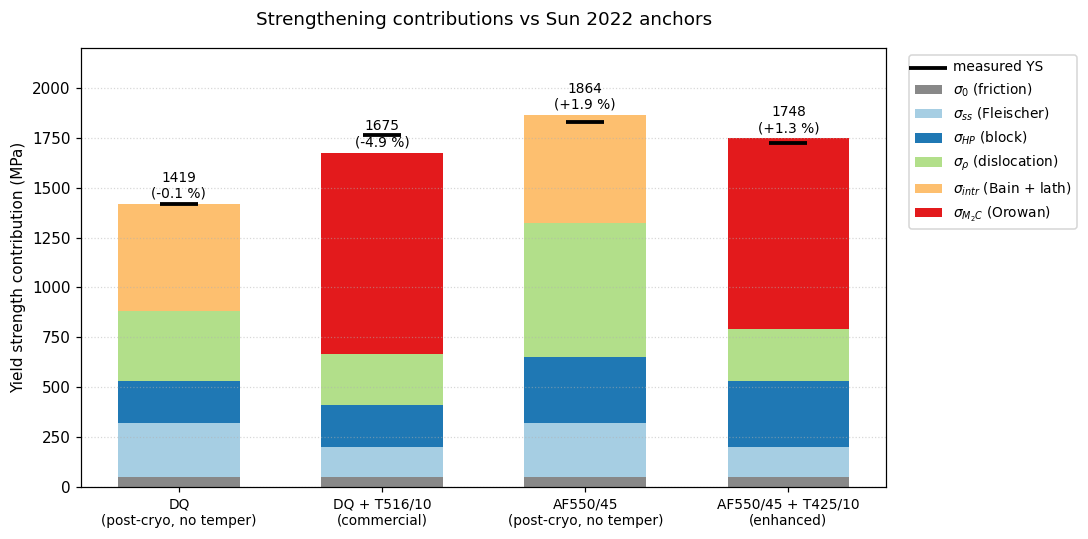

In [4]:
fig = plot_contributions(reports)
plt.show()

## 4. Predicted vs measured at a glance

Side-by-side bars show the model passes all four anchors within ±5%.
Failed anchors would render in red.

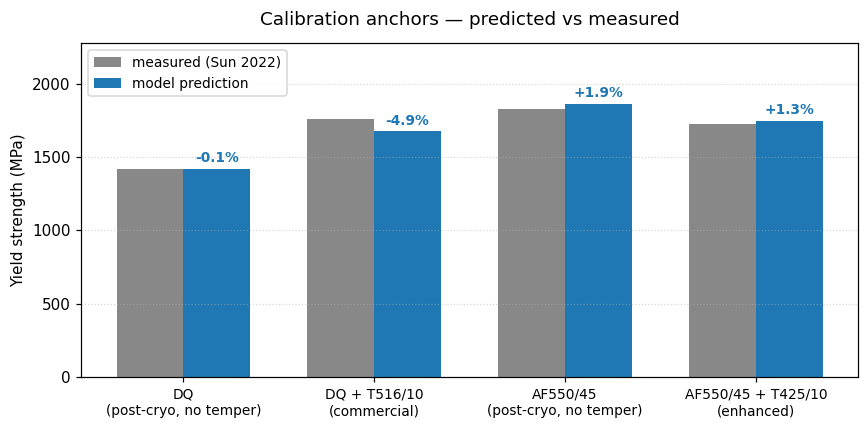

In [5]:
fig = plot_anchor_dashboard(reports)
plt.show()

## 5. Decomposition table (numerical)

Same data as the stacked bar, but tabular.

In [6]:
import pandas as pd
rows = []
for r in reports:
    row = {'Anchor': r.anchor_label, 'Measured': r.measured_YS_MPa, 'Predicted': r.predicted_YS_MPa, 'Miss%': r.miss_pct}
    row.update({k: round(v, 1) for k, v in r.contributions_MPa.items()})
    rows.append(row)
pd.DataFrame(rows).set_index('Anchor').T

Anchor,"DQ (post-cryo, no temper)",DQ + T516/10 (commercial),"AF550/45 (post-cryo, no temper)",AF550/45 + T425/10 (enhanced)
Measured,1420.000000,1762.000000,1830.000000,1726.000000
Predicted,1419.180643,1675.485962,1864.455510,1748.392308
Miss%,-0.057701,-4.909991,1.882815,1.297353
sigma_0,50.000000,50.000000,50.000000,50.000000
sigma_ss,271.300000,149.800000,271.300000,149.800000
sigma_HP,211.700000,211.700000,332.000000,332.000000
sigma_rho,346.600000,254.300000,671.600000,261.100000
sigma_intr,539.500000,0.000000,539.500000,0.000000
sigma_M2C,NaN,1009.600000,NaN,955.600000


## 6. Tempering sweep — DQ + tempering at varying T, t

What does the model predict if we vary tempering temperature and time, holding
the rest of the DQ microstructure fixed? This shows the precipitation-strengthening
engagement curve. The red star marks the Sun 2022 anchor (516 °C / 10 h) for
reference.

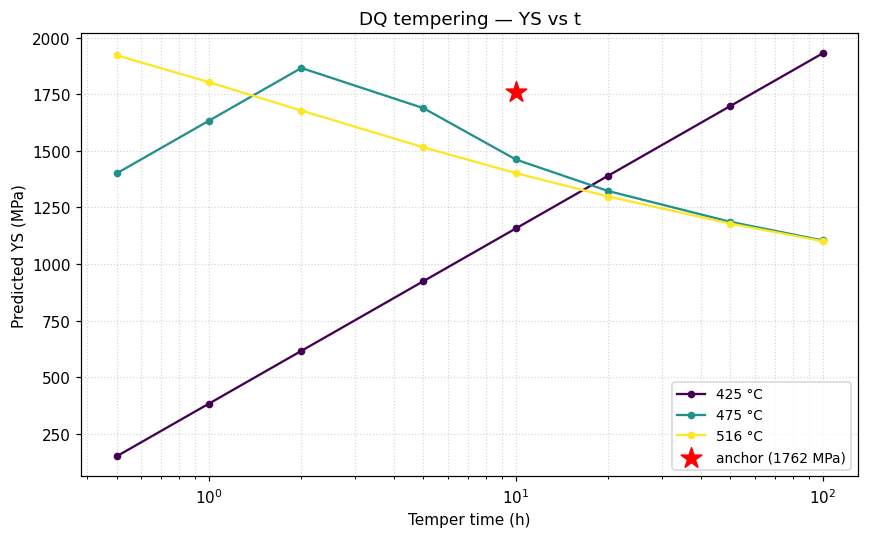

In [7]:
from m54model.calibration.anchors import _matrix_tempered

def predict_dq_tempered(T_celsius: float, t_hours: float) -> float:
    base = sun_2022_dq_t516_10()  # block, rho, etc.
    m2c = m2c_population_dq_tempered(T_celsius, t_hours)
    state = MicrostructuralState(
        state='dq_tempered',
        block_width_um=base.block_width_um,
        dislocation_density_per_m2=base.dislocation_density_per_m2,
        f_austenite=0.0,
        matrix_at_frac=base.matrix_at_frac,
        wt_pct_C_in_solution=0.003,
        precipitates=[m2c],
        label=f'DQ + T{T_celsius:.0f}/{t_hours:.1f}',
    )
    return assemble_yield_strength(state).sigma_y_MPa

t_hours = np.array([0.5, 1, 2, 5, 10, 20, 50, 100])
T_grid = [425.0, 475.0, 516.0]
curves = {T: (t_hours, [predict_dq_tempered(T, t) for t in t_hours]) for T in T_grid}
fig = plot_tempering_sweep(curves, title='DQ tempering — YS vs t', anchor_t_h=10, anchor_y_MPa=1762)
plt.show()

## 7. AF vs DQ at the same temper

Compare the two processing routes at identical temper conditions. The model says
AF beats DQ across the board (because of refined block + ausforming-accelerated M2C).
Sun 2022 measures AF+T (T425/10) at 1726 vs DQ+T (T516/10) at 1762 — the **opposite**
ordering. This is the direction-of-effect bias documented in
[`docs/FINDINGS.md`](../docs/FINDINGS.md) §5 and worth investigating in Phase 2.5.

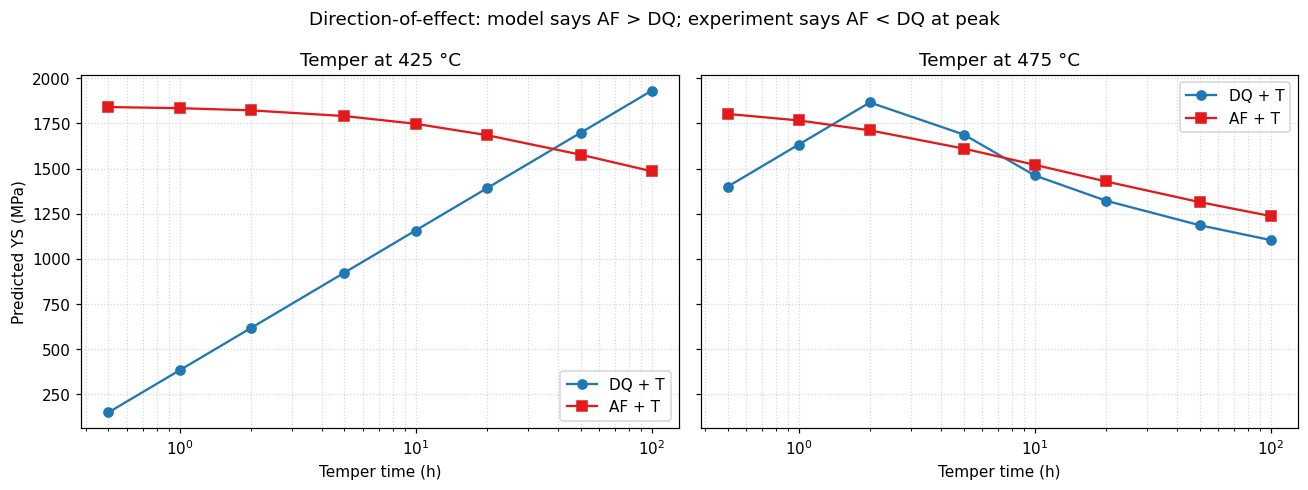

In [8]:
def predict_af_tempered(T_celsius: float, t_hours: float) -> float:
    base = sun_2022_af550_45_t425_10()
    m2c = m2c_population_af_tempered(T_celsius, t_hours)
    state = MicrostructuralState(
        state='af_tempered',
        block_width_um=base.block_width_um,
        dislocation_density_per_m2=base.dislocation_density_per_m2,
        f_austenite=0.0,
        matrix_at_frac=base.matrix_at_frac,
        wt_pct_C_in_solution=0.003,
        precipitates=[m2c],
        label=f'AF + T{T_celsius:.0f}/{t_hours:.1f}',
    )
    return assemble_yield_strength(state).sigma_y_MPa

T_grid = [425.0, 475.0, 516.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, T in zip(axes[:2], (425.0, 475.0)):
    dq_ys = [predict_dq_tempered(T, t) for t in t_hours]
    af_ys = [predict_af_tempered(T, t) for t in t_hours]
    ax.plot(t_hours, dq_ys, '-o', label='DQ + T', color='#1f78b4')
    ax.plot(t_hours, af_ys, '-s', label='AF + T', color='#e31a1c')
    ax.set_xscale('log')
    ax.set_xlabel('Temper time (h)')
    ax.set_title(f'Temper at {T:.0f} °C')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()
axes[0].set_ylabel('Predicted YS (MPa)')
fig.suptitle('Direction-of-effect: model says AF > DQ; experiment says AF < DQ at peak')
fig.tight_layout()
plt.show()

## 8. M2C population evolution

How the M2C precipitate population changes with temper time at 425 °C, comparing
DQ vs AF kinetics. AF state has lower nucleation activation energy (137 vs
407 kJ/mol per Cho 2015) so it reaches saturation V_f much faster.

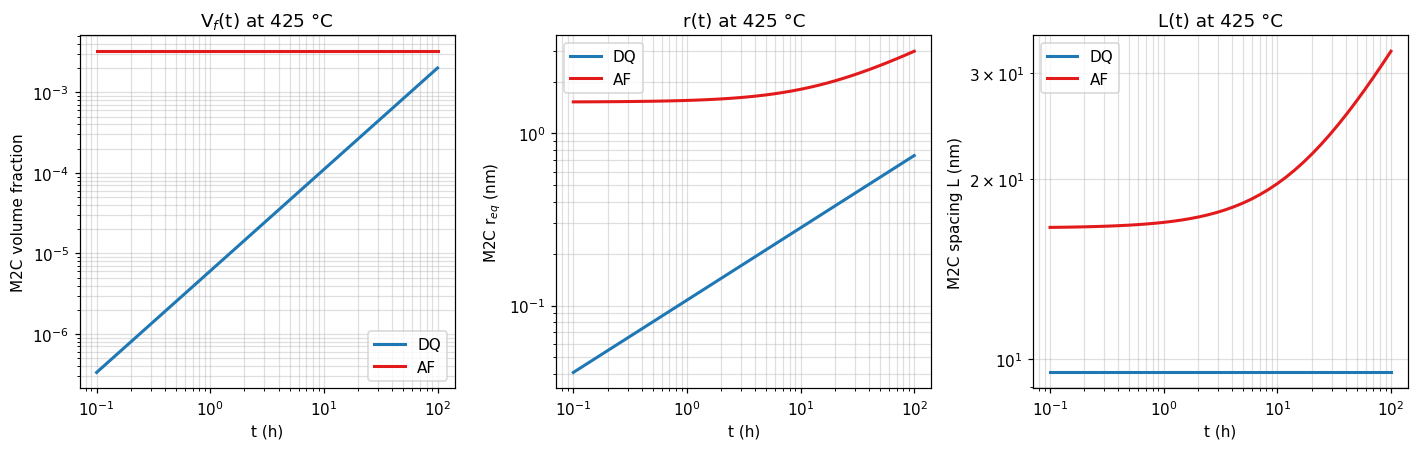

In [9]:
t_log = np.logspace(np.log10(0.1), np.log10(100), 40)
T = 425.0
dq_pops = [m2c_population_dq_tempered(T, t) for t in t_log]
af_pops = [m2c_population_af_tempered(T, t) for t in t_log]

# All three panels use log-y because DQ vs AF span ~100× in V_f and ~5-10× in r/L.
# Linear y on r and L would render the DQ curves nearly flat at zero.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (attr, ylabel, title) in zip(axes, [
    ('volume_fraction',     'M2C volume fraction',  'V$_f$(t) at 425 °C'),
    ('equivalent_radius_nm','M2C r$_{eq}$ (nm)',     'r(t) at 425 °C'),
    ('spacing_nm',          'M2C spacing L (nm)',    'L(t) at 425 °C'),
]):
    dq_vals = [getattr(p, attr) or 1e-12 for p in dq_pops]
    af_vals = [getattr(p, attr) or 1e-12 for p in af_pops]
    ax.plot(t_log, dq_vals, '-', label='DQ', color='#1f78b4', linewidth=2)
    ax.plot(t_log, af_vals, '-', label='AF', color='#e31a1c', linewidth=2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('t (h)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.4)

fig.tight_layout()
plt.show()

## 9. Sensitivity analysis — what if K_HP is wrong?

Sun fits K_HP = 230 MPa·µm^½ on M54; Wang and Zhu use 300 for generic SH steel.
Sweeping over a range to see how DQ+T anchor moves.

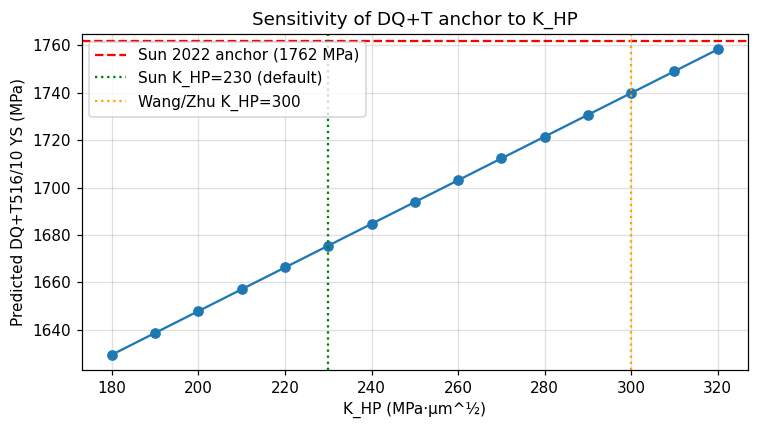

In [10]:
from m54model.constants import StrengtheningConstants

K_range = np.linspace(180, 320, 15)
state = sun_2022_dq_t516_10()
predicted = [
    assemble_yield_strength(
        state,
        constants=StrengtheningConstants(M_taylor=2.5, alpha_BH=0.38, K_HP_MPa_um_half=K),
    ).sigma_y_MPa
    for K in K_range
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, predicted, '-o', color='#1f78b4')
ax.axhline(SUN_2022_DQ_T516_10.YS_MPa, color='red', linestyle='--',
           label=f'Sun 2022 anchor ({SUN_2022_DQ_T516_10.YS_MPa} MPa)')
ax.axvline(230, color='green', linestyle=':', label='Sun K_HP=230 (default)')
ax.axvline(300, color='orange', linestyle=':', label='Wang/Zhu K_HP=300')
ax.set_xlabel('K_HP (MPa·µm^½)'); ax.set_ylabel('Predicted DQ+T516/10 YS (MPa)')
ax.set_title('Sensitivity of DQ+T anchor to K_HP'); ax.legend(); ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

## 10. Where to go from here

**Try modifying:**
- The composition in [`src/m54model/alloys/ferrium_m54.py`](../src/m54model/alloys/ferrium_m54.py)
  to model a hypothetical alloy variant.
- Block size or dislocation density in the anchor factories
  ([`src/m54model/calibration/anchors.py`](../src/m54model/calibration/anchors.py))
  to see what microstructural levers move YS most.
- The Fleischer β placeholders in [`src/m54model/constants.py`](../src/m54model/constants.py)
  for W, V, C, Ti — sensitivity is small but not zero.

**Coming next:**
- Phase 3 — TRIP toughening submodel (Patel-Cohen + Olson-Cohen) calibrated
  against your 0/20/40/60 % cw/cr austenite-content data.
- Phase 2.5 — investigate the AF+T vs DQ+T direction-of-effect bias surfaced
  in cell 7.